In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Callable, Tuple
from multi_q_base_forecasters import generate_quantile_data, create_quantile_aware_forecaster_class
from metrics import pinball_loss, create_scoring_function_class


# ============================================================================
# Efficient V_n Computation with Precomputation
# ============================================================================

class VnComputer:
    """
    Efficient computation of V_n with precomputed cumulative sums.
    
    The naive O(N*m^2) approach computes V_n for each n by summing over
    all i and s. We can reduce this to O(m) per time step by precomputing
    cumulative sums.
    """
    
    def __init__(self, weights: np.ndarray, thetas: np.ndarray, forecast_values: np.ndarray, tol: float = 1e-10):
        """
        Initialize V_n computer with precomputed arrays.
        
        Parameters
        ----------
        weights : np.ndarray
            Shape (N, m) where weights[s, i] = w_i^s
            s is 0-indexed time (0 to N-1)
            i is 0-indexed quantile (0 to m-1)
        thetas : np.ndarray (m,)
        forecast_values : np.ndarray (N, m)
        indicators : np.ndarray
            Shape (N, m) where indicators[s, i] = I(theta_i < f_i^s) in {0, 1}
        """

        self.weights = np.asarray(weights, dtype=np.float64)
        self.thetas = np.asarray(thetas, dtype=np.float64)
        forecast_values = np.asarray(forecast_values, dtype=np.float64)
        self.indicators = np.asarray(thetas[None, :] < forecast_values, dtype=np.float64)
        self.tol = tol
        
        self.N = weights.shape[0]
        self.m = weights.shape[1]
        
        assert weights.shape == forecast_values.shape, \
            f"Shape mismatch: {weights.shape} vs {forecast_values.shape}"
        assert thetas.shape[0] == forecast_values.shape[1], \
            f"Shape mismatch: {thetas.shape} vs {forecast_values.shape[1]}"
        
        # Precompute cumulative sums for efficiency
        self._precompute_cumulative_sums()
    
    def _precompute_cumulative_sums(self):
        """
        Precompute cumulative sums to enable O(m) V_n computation.
        
        For each quantile i:
        - past_sum[n, i] = sum_{s=1}^{n+1} w_i^s * I(theta_i < f_i^s)
        - future_sum[n, i] = sum_{s=n+2}^{N} w_i^s * (1 - I(theta_i < f_i^s))
        """
    
        # Compute from time 0 (index 0 is time 1 in the paper)
        weighted_indicators = self.weights * self.indicators
        self.past_cumsum = np.zeros((self.N + 1, self.m), dtype=np.float64)
        # Cumulative sum along time axis: axis=0
        # past_cumsum[n, i] = sum of first n elements (s=1 to n)
        for n in range(self.N + 1):
            if n==0:
                self.past_cumsum[0, :] = 0
            else:
                self.past_cumsum[n, :] = self.past_cumsum[n-1, :] + weighted_indicators[n-1, :] # weighted_indicators[s,i] = w_{i}^{s-1}
        
        # Future cumulative sum: sum_{s=n+1}^{N} w_i^s * (1 - I(theta_i < f_i^s))
        # future_cumsum[n, i] = sum of elements from n+1 to N (s=n+1 to N)
        weighted_indicators_complement = self.weights - weighted_indicators
        
        # Reverse cumulative sum
        self.future_cumsum = np.zeros((self.N + 1, self.m), dtype=np.float64)
        for n in range(self.N, 0, -1):
            if n == self.N:
                self.future_cumsum[self.N, :] = 0
            else:
                self.future_cumsum[n, :] = self.future_cumsum[n+1, :] + weighted_indicators_complement[n, :]    # s=n+1

    
    def compute_Vn(self, n: int, j_opt_min: int = 0) -> Tuple[float, int]:
        """
        Compute V_n for time step n.
        
        V_n = min_{j in [m]} (
            sum_{i=j}^{m-1} past_cost[i] + sum_{i=0}^{j-1} future_cost[i]
        )
        
        Parameters
        ----------
        n : int
        j_opt_min : int
            Minimum j* to consider (preventing crossing between j_n*)
        
        Returns
        -------
        V_n : float
            Minimum cost value
        j_opt : int
            Optimal cut point (0-indexed, j in [0, m])
        """
        if n == 0:
            return 0.0, 0
        if n == self.N:
            return 0.0, self.m
        assert 0 < n < self.N
        
        costs = np.zeros(self.m+1, dtype=np.float64)
        min_cost = np.inf
        j_opt = j_opt_min

        for j in range(j_opt_min, self.m+1):
            if j == j_opt_min:
                past_sum = self.past_cumsum[n, j_opt_min:].sum()
                if j_opt_min == 0:
                    future_sum = 0.0
                else:
                    future_sum = self.future_cumsum[n, :j_opt_min].sum()
                costs[j_opt_min] = past_sum + future_sum
                min_cost = costs[j_opt_min]
            else:
                costs[j] = costs[j-1] - self.past_cumsum[n, j-1] + self.future_cumsum[n, j-1]
                if costs[j] < min_cost - self.tol:
                    min_cost = costs[j]
                    j_opt = j
        
        if min_cost == np.inf:
            raise ValueError(f"min_cost is inf at n={n}, j_opt_min={j_opt_min}")
        
        # print(f'Vn compute at n={n}, j_opt_min={j_opt_min}, j_opt={j_opt}, min_cost={min_cost}')
        # print(costs)

        return min_cost, j_opt

    
    def compute_all_Vn(self) -> Tuple[np.ndarray, np.ndarray, List[np.ndarray]]:
        """
        Compute V_n for all n in [0, N].
        
        Returns
        -------
        V_n_values : np.ndarray
            Shape (N+1,) containing V_n for n=0 to N
        j_optimal : np.ndarray
            Shape (N+1,) containing optimal j* for each n
        """
        Vn_values = np.zeros(self.N + 1, dtype=np.float64)
        j_optimal = np.zeros(self.N + 1, dtype=np.int32)
        
        Vn_values[0] = 0.0
        j_optimal[0] = 0
        
        for n in range(1, self.N + 1):
            Vn, j_opt = self.compute_Vn(n=n, j_opt_min=j_optimal[n-1])
            Vn_values[n] = Vn
            j_optimal[n] = j_opt
        
        return Vn_values, j_optimal


def single_q_minmax_solver2(    # for multi-q case. Should be able to merge with single_q_minmax_solver
    theta_weights: np.ndarray,      # (m,)
    forecast_values: np.ndarray,    # (m,)
    thetas: np.ndarray,             # (m,)
    eq_value: float = 0.0,
    j_opt_pre: int = 0,        # minimum value of k_star, j_{n-1}^*
    j_opt_n: int = np.inf,   # maximum value of k_star, j_n^*
    tol: float = 1e-10,
) -> dict:
    """
    Solve the minmax problem for a single quantile level.
    Contains randomness in the choice of phat.
    """
    m = len(thetas)
    j_opt_pre = max(j_opt_pre, 0)
    j_opt_n = min(j_opt_n, m)
    assert j_opt_pre <= j_opt_n
    
    assert len(theta_weights) == len(forecast_values) == len(thetas)
    # assert np.isclose(np.sum(theta_weights), 1.0), f"theta_weights sum: {np.sum(theta_weights)}"  # This is false in each quantile level
    weighted_weights = np.sum(theta_weights * (thetas < forecast_values).astype(float))
    Bk_pre = np.concatenate([[-weighted_weights], np.cumsum(theta_weights) - weighted_weights])    # [0 (placeholder), B_1, ..., B_m=0]: Bk_pre[j] = sum_{i=0}^{j-1} w_i - \sum_{i=0}^{m-1} w_i * I(theta_i < f_i^s)
    
    if np.isclose(Bk_pre[j_opt_pre], eq_value, atol=tol):
        return {
            "phat": j_opt_pre / m,
            "k_star": j_opt_pre,
            "k_star_prob": 1.0,
        }
    assert Bk_pre[j_opt_pre] < eq_value + tol, f"j_(n-1)*: {j_opt_pre}, Bk_pre[j_opt_pre]: {Bk_pre[j_opt_pre]}, eq_value: {eq_value}"
    assert eq_value < Bk_pre[j_opt_n] + tol, f"j_n*: {j_opt_n}, Bk_pre[j_opt_n]: {Bk_pre[j_opt_n]}, eq_value: {eq_value}"
    assert j_opt_pre < j_opt_n

    # Bk_pre[j] = \sum_{i=0}^{j-1} w_i - \sum_{i=0}^{m-1} w_i * I(theta_i < f_i^s). 
    # From theory, there exists k_n* s.t. j_{n-1}* <= k_n* < j_n* and \sum_{i=0}^{k_n*} w_i >= VALUE and \sum_{i=0}^{k_n*-1} w_i < VALUE.
    # So the biggest value of j to check Bk_pre[j] \geq VALUE is j_n*. Since Bk_pre[j_n*] = \sum_{i=0}^{j_n*-1 = <max value of k_n*>} w_i - \sum_{i=0}^{m-1} w_i \indi,
    for j in range(j_opt_pre+1, j_opt_n+1):  
        if Bk_pre[j] >= eq_value - tol:
            assert not np.isclose(Bk_pre[j-1], Bk_pre[j], atol=tol), f'Bk_pre[j-1]: {Bk_pre[j-1]}, Bk_pre[j]: {Bk_pre[j]}, eq_value: {eq_value}'
            k_star = j-1
            if np.isclose(eq_value, Bk_pre[j-1]):
                k_star_prob = 0.0
            elif np.isclose(eq_value, Bk_pre[j]):
                k_star_prob = 1.0
            else:
                k_star_prob = (eq_value - Bk_pre[j-1]) / (Bk_pre[j] - Bk_pre[j-1])
            phat = np.random.choice([k_star / m, (k_star+1) / m], p=[k_star_prob, 1.0-k_star_prob])
            return {
                "phat": phat,
                "k_star": k_star,
                "k_star_prob": k_star_prob,
            }

    assert False, "Single-q search for multi-q optimiation ERROR. Should not reach here." + f'j_opt_pre: {j_opt_pre}, j_opt_n: {j_opt_n}, eq_value: {eq_value}, Bk_pre: {Bk_pre}'


def multi_q_minmax_solver(
    theta_weights: np.ndarray,  # (N, m)
    thetas: np.ndarray,  # (m,)
    forecast_values: np.ndarray,  # (N, m)
) -> dict:
    """
    Solve the minmax problem for a single quantile level.
    Contains randomness in the choice of phat.
    """
    N = theta_weights.shape[0]
    m = len(thetas)
    assert theta_weights.shape[1] == forecast_values.shape[1] == m
    assert theta_weights.shape[0] == forecast_values.shape[0] == N
    assert np.isclose(np.sum(theta_weights), 1.0)

    # First find V_n and j_n^*
    Vn_computer = VnComputer(weights = theta_weights, 
                            thetas = thetas, 
                            forecast_values = forecast_values
                            )
    Vn_values, j_optimal =  Vn_computer.compute_all_Vn()

    # print(f"Vn_values: {Vn_values}")
    # print(f"j_optimal: {j_optimal}")
    phat_dict_list = []

    for n in range(N):  # n=0 means first quantile (corresponds to n=1 in paper), eq_value = -V1, j_opt_pre = j_0^*
        phat_dict = single_q_minmax_solver2(theta_weights=theta_weights[n,:],      # (m,)
                            forecast_values=forecast_values[n,:],    # (m,)
                            thetas=thetas,             # (m,)
                            eq_value=Vn_values[n] - Vn_values[n+1],     
                            j_opt_pre=j_optimal[n],
                            j_opt_n=j_optimal[n+1],
                            )
        phat_dict_list.append(phat_dict)

    return phat_dict_list, Vn_values


def minimax_value_neg(alpha_list: np.ndarray, Vn_values: np.ndarray) -> float:
    """
    Negation of minimax value of negative of the minimax value.
    = - \sum_{n=1}^{N-1} (\tau_{n+1} - \tau_n) V_n
    """
    N = alpha_list.shape[0]
    return np.sum(alpha_list * (Vn_values[0:N] - Vn_values[1:N+1]))


def single_q_omnipred_error(
    predictions: np.ndarray,    # (T,)
    Y: np.ndarray,              # (T,)
    scoring_functions: List[Callable],  # (m,)
) -> float:
    """
    Compute the omniprediction error for given quantile prediction.
    """

    return np.array([S(predictions, Y) for S in scoring_functions])



# ============================================================================
# Modified Helper Functions for Multi-Quantile
# ============================================================================
def get_multiquantile_forecaster_predictions(
    x_t: float,
    forecasters: List[Callable],
    alpha_list: np.ndarray,
) -> np.ndarray:
    """
    Get predictions from all forecasters at all quantile levels.
    
    Parameters
    ----------
    x_t : float
        Current input sample
    forecasters : List[Callable]
        List of multi-quantile forecasters
    alpha_list : np.ndarray
        Array of quantile levels
    
    Returns
    -------
    forecaster_preds : np.ndarray
        Shape (N, F) where F = number of forecasters
        forecaster_preds[i_alpha, j] = prediction from forecaster j at alpha_i
    """
    F = len(forecasters)
    n_alphas = len(alpha_list)
    
    forecaster_preds = np.zeros((F, n_alphas), dtype=np.float64)  # Transpose later
    
    for j, forecaster in enumerate(forecasters):
        # Each forecaster returns predictions for all alphas
        preds = forecaster(x_t)  # Shape (n_alphas,)
        forecaster_preds[j, :] = preds
    
    return forecaster_preds.T


def omni_error_from_scores(scores: np.ndarray):
    # scores: (T, N, m, ..)
    # return: (T, ..)
    if scores.ndim == 3:
        return np.max(scores.cumsum(axis=0), axis=(1,2)) / (np.arange(scores.shape[0]) + 1)
    elif scores.ndim == 4:
        return np.max(scores.cumsum(axis=0), axis=(1,2)) / (np.arange(scores.shape[0])[:, None] + 1)
    else:
        raise ValueError(f"scores.ndim: {scores.ndim}")



# ============================================================================
# Main Omniprediction Experiment
# ============================================================================

def omniprediction_multiq(T: int = 500, m: int = 10, F: int = 5, 
                        alpha_list: List[float] = [0.5], eta: float = 0.1,
                        eta_f: float = 0.1, seed: int = 42):
    """
    Run omniprediction experiment and compare against base forecasters.
    
    Parameters
    ----------
    T : int
        Time horizon / number of samples
    m : int
        Number of discretized theta values
    F : int
        Number of base forecasters
    alpha_list : List[float]
        List of quantile levels
    eta : float
        Learning rate for weights w_i
    eta_f : float
        Learning rate for forecaster selection v_{i,j}
    seed : int
        Random seed
    
    Returns
    -------
    results : dict
        Dictionary containing all results
    """
    print("="*70)
    print("OMNIPREDICTION MULTI-QUANTILE EXPERIMENT")
    print("="*70)
    
    np.random.seed(seed)
    
    # Setup
    print(f"\nSetup:")
    print(f"  Time horizon: T = {T}")
    print(f"  Quantile level: alpha = {alpha_list} ({len(alpha_list)} levels)")
    print(f"  Discretized thetas: m = {m}")
    print(f"  Base forecasters: F = {F}")
    
    # Generate data
    alpha_list = np.array(alpha_list)
    assert len(alpha_list.shape) == 1
    N = alpha_list.shape[0]
    X, Y = generate_quantile_data(n=T, m=m, seed=seed)
    print(f"\nData:")
    print(f"  X range: [{X.min():.3f}, {X.max():.3f}]")
    print(f"  Y range: [{Y.min():.3f}, {Y.max():.3f}]")
    
    # Create scoring function class S_alpha
    scoring_functions, thetas = create_scoring_function_class(
        alpha_list=alpha_list,
        m=m
    )
    print(f"  Number of theta values: {m}")
    print(f"  Theta range: [{thetas.min():.3f}, {thetas.max():.3f}]")
    
    # Create base forecaster class
    forecasters, forecaster_names = create_quantile_aware_forecaster_class(alpha_list=alpha_list, F=F, seed=seed)
    print(f"\nBase forecasters C = {{f_1, ..., f_F}}:")
    for i, name in enumerate(forecaster_names):
        print(f"  {i+1}. {name}")
    
    # Initialize algorithm state
    w = np.ones((N, m)) / (N*m)  # Uniform weights over thetas
    v = np.ones((N, m, F)) / F  # Uniform weights over forecasters for each theta
    f_selected_indices = np.zeros((N, m), dtype=np.int32)  # Initially all use first forecaster
    
    pinball_v = np.ones((N,F)) / F  # each quantilie level separately
    pinball_f_selected_indices = np.zeros(N, dtype=np.int32)
    ql_v = np.ones(F) / F  # all quantile levels together
    ql_f_selected_index = 0
    
    # Storage for regrets over time
    phat_history = np.zeros((T, N))
    w_history = np.zeros((T, N, m))
    v_history = np.zeros((T, N, m, F))
    minimax_value_history = np.zeros((T,))
    omni_error_history = np.zeros((T, N, m))
    preds_history = np.zeros((T, N, F))     # Predictions of each forecaster
    forecasters_score_history = np.zeros((T, N, m, F))
    forecasters_selection_history = np.zeros((T, N, m))

    pinball_selection_history = np.zeros((T, N))
    pinball_preds_history = np.zeros((T, N))
    ql_selection_history = np.zeros((T))
    ql_preds_history = np.zeros((T, N))
    
    print(f"\nRunning omniprediction algorithm...")
    
    for t in tqdm(range(T)):
        x_t = X[t]
        y_t = Y[t]
        
        # Step 1: Compute P_t
        all_forecaster_preds = get_multiquantile_forecaster_predictions(
            x_t=x_t, forecasters=forecasters, alpha_list=alpha_list
        )  # Shape (N, F)
        
        # Select one forecaster per theta level (currently using index)
        # Use advanced NumPy indexing for compactness and speed
        row_idx = np.arange(N)[:, None]
        col_idx = f_selected_indices
        # print(row_idx)
        # print(col_idx)
        forecaster_preds = all_forecaster_preds[row_idx, col_idx]
        assert forecaster_preds.shape == (N, m)


        phat_dict_list, Vn_values = multi_q_minmax_solver(
            theta_weights=w,
            thetas=thetas,
            forecast_values=forecaster_preds,
        )
        minimax_value_history[t] = minimax_value_neg(alpha_list=alpha_list, Vn_values=Vn_values)

        phat = np.array([phat_dict["phat"] for phat_dict in phat_dict_list])
        phat_history[t,:] = phat
        k_star = np.array([phat_dict["k_star"] for phat_dict in phat_dict_list])
        k_star_prob = np.array([phat_dict["k_star_prob"] for phat_dict in phat_dict_list])
        
        # Step 2: Compute expected score under P_t
        phat_score = np.stack([
            k_star_prob[n] * np.array([S(k_star[n]/m, y_t) for S in scoring_functions[n]]) +
            (1-k_star_prob[n]) * np.array([S((k_star[n]+1)/m, y_t) for S in scoring_functions[n]])
            for n in range(N)
        ])
        f_selected_score = np.stack([
            np.array([S(forecaster_preds[n,i], y_t) for i, S in enumerate(scoring_functions[n])])
            for n in range(N)
        ])
        
        assert phat_score.shape == (N, m), f'phat_score.shape: {phat_score.shape}, N: {N}, m: {m}'
        assert f_selected_score.shape == (N, m), f'f_selected_score.shape: {f_selected_score.shape}, N: {N}, m: {m}'
        
        # Step 3: Update weights w_i
        w_history[t,:] = w
        v_history[t,:,:] = v
        log_w = np.log(w + 1e-10)
        log_w += eta * (phat_score - f_selected_score)
        
        # Normalize in log space
        max_log_w = np.max(log_w)
        log_w -= max_log_w
        w = np.exp(log_w)
        w /= np.sum(w)
        
        # Step 4: Update forecaster selection v_{i,j} (vectorized implementation)
        preds = all_forecaster_preds    # (N, F)
        preds_history[t,:, :] = preds
        # Fix TypeError: list indices must be integers or slices, not tuple
        scores = np.stack([
            np.stack([
                [scoring_functions[n][i](preds[n, j], y_t) for j in range(F)]
                for i in range(m)
            ])
            for n in range(N)
        ])
        assert scores.shape == (N, m, F)
        
        log_v = np.log(v + 1e-10)
        log_v -= eta_f * scores
        
        # Normalize in log-space for numerical stability
        max_log_v = np.max(log_v, axis=2, keepdims=True)
        log_v -= max_log_v
        
        v = np.exp(log_v)
        v /= np.sum(v, axis=2, keepdims=True)
        
        # Step 4-2: Hedge algorithm using pinball loss
        # Store selection history in vectorized manner
        pinball_selection_history[t, :] = pinball_f_selected_indices
        pinball_preds_history[t, :] = preds[np.arange(N), pinball_f_selected_indices]
        
        # Vectorized pinball loss computation and update
        # Compute pinball losses for all (N, F) at once
        pinball_losses = pinball_loss(preds, Y[t], alpha_list[:, None])  # expects broadcasting: preds (N, F), alpha_list (N,1) -> (N,F)
        assert pinball_losses.shape == (N, F)

        # Vectorized update of pinball_v (N,F)
        pinball_v = np.log(pinball_v + 1e-10)
        pinball_v -= eta_f * pinball_losses
        pinball_v -= np.max(pinball_v, axis=1, keepdims=True)
        pinball_v = np.exp(pinball_v)
        pinball_v /= np.sum(pinball_v, axis=1, keepdims=True)

        # Vectorized forecaster selection for all n at once
        # Use cumulative sums for np.random.choice efficiency
        cum_v = np.cumsum(pinball_v, axis=1)
        r = np.random.rand(N, 1)
        pinball_f_selected_indices = (cum_v > r).argmax(axis=1)



        # Step 4-3: Hedge algorithm using QL loss
        ql_selection_history[t] = ql_f_selected_index
        ql_preds_history[t,:] = preds[:, ql_f_selected_index]
        ql_loss = np.mean(pinball_losses, axis=0)
        ql_v = np.log(ql_v + 1e-10)
        ql_v -= eta_f * ql_loss
        ql_v -= np.max(ql_v)
        ql_v = np.exp(ql_v)
        ql_v /= np.sum(ql_v)
        ql_f_selected_index = np.random.choice(F, p=ql_v)


        # Step 5: Sample new forecasters
        for n in range(N):
            for i in range(m):
                j_ni = np.random.choice(F, p=v[n,i,:])
                f_selected_indices[n,i] = j_ni
    
        # Compute regret at time t
        forecasters_selection_history[t,:,:] = f_selected_indices
        forecasters_score_history[t,:,:,:] = scores
        omni_error_history[t,:,:] = np.stack([[S(phat[n], Y[t]) for S in scoring_functions[n]] for n in range(N)])
    
    print(f"\n" + "="*70)
    print("RESULTS")
    print("="*70)
    
    # print(f"\nOmniprediction error (from learned P):")
    # print(f"  sup_{{S in S_alpha}} E[S(P(X), Y)] = {omni_error:.6f}")
    
    # # Compute regret of each base forecaster
    # print(f"\nRegret of each base forecaster:")
    # print(f"  sup_{{S in S_alpha}} E[S(f_j(X), Y)]")

    omni_score_trace = omni_error_from_scores(omni_error_history)
    assert omni_score_trace.shape == (T,)

    forecasters_score_trace = omni_error_from_scores(forecasters_score_history)
    assert forecasters_score_trace.shape == (T, F)

    best_forecaster_score_trace = forecasters_score_trace.min(axis=1)
    
    # Theoretical bound
    # theoretical_bound = np.sqrt(np.log(m * F) / T)
    # print(f"\nTheoretical omniprediction guarantee:")
    # print(f"  O(sqrt(log(m*F)/T)) = O(sqrt({np.log(m*F):.2f}/{T}))")
    # print(f"                      = O({theoretical_bound:.6f})")
    
    # Return results
    return {
        'phat_history': phat_history,
        'w_history': w_history,
        'v_history': v_history,
        'minimax_value_history': minimax_value_history, # (T,)
        'omni_error_history': omni_error_history,   # (T, N, m) 
        'forecasters_preds_history': preds_history, # (T, N, F)
        'forecasters_score_history': forecasters_score_history, # (T, N, m, F)
        'forecasters_selection_history': forecasters_selection_history, # (T, N, m)
        'omni_score_trace': omni_score_trace,   # (T,)
        'forecasters_score_trace': forecasters_score_trace, # (T, F)    
        'best_forecaster_score_trace': best_forecaster_score_trace, # (T,)
        'thetas': thetas,
    
        'pinball_selection_history': pinball_selection_history,     # (T, N)
        'pinball_preds_history': pinball_preds_history,             # (T, N)
        'ql_selection_history': ql_selection_history,               # (T,)
        'ql_preds_history': ql_preds_history,                       # (T, N)
        
        'Y': Y,
        'X': X,
        'T': T,
        'm': m,
        'F': F,
        'alpha_list': alpha_list,
        'forecaster_names': forecaster_names,
        # 'theoretical_bound': theoretical_bound,
    }


In [186]:
# ============================================================================
# Run Experiment
# ============================================================================

T = 1000
m = 50
F = 5

alpha_list = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
results = omniprediction_multiq(T=T, m=m, F=F, alpha_list=alpha_list, eta=np.sqrt(np.log(m)/T), eta_f=np.sqrt(np.log(F)/T))
print("\n" + "="*70)
print("Experiment complete!")
print("="*70)

OMNIPREDICTION MULTI-QUANTILE EXPERIMENT

Setup:
  Time horizon: T = 1000
  Quantile level: alpha = [0.1 0.3 0.5 0.7 0.9] (5 levels)
  Discretized thetas: m = 50
  Base forecasters: F = 5

Data:
  X range: [0.005, 1.000]
  Y range: [0.000, 1.000]
  Number of theta values: 50
  Theta range: [0.010, 0.990]

Base forecasters C = {f_1, ..., f_F}:
  1. Lower Tail Specialist
  2. Central Tendency
  3. Upper Tail Specialist
  4. Conservative (Low Variance)
  5. Aggressive (High Variance)

Running omniprediction algorithm...


100%|██████████| 1000/1000 [00:08<00:00, 115.33it/s]


RESULTS

Experiment complete!


In [187]:
# ============================================================================
# Run Experiment
# ============================================================================

T = 1000
m = 50
F = 5

results_dict = {}
alpha_list = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
for alpha in alpha_list:
    results_dict[alpha] = omniprediction_multiq(T=T, m=m, F=F, alpha_list=[alpha], eta=np.sqrt(np.log(m)/T), eta_f=np.sqrt(np.log(F)/T))
print("\n" + "="*70)
print("Experiment complete!")
print("="*70)

OMNIPREDICTION MULTI-QUANTILE EXPERIMENT

Setup:
  Time horizon: T = 1000
  Quantile level: alpha = [np.float64(0.1)] (1 levels)
  Discretized thetas: m = 50
  Base forecasters: F = 5

Data:
  X range: [0.005, 1.000]
  Y range: [0.000, 1.000]
  Number of theta values: 50
  Theta range: [0.010, 0.990]

Base forecasters C = {f_1, ..., f_F}:
  1. Lower Tail Specialist
  2. Central Tendency
  3. Upper Tail Specialist
  4. Conservative (Low Variance)
  5. Aggressive (High Variance)

Running omniprediction algorithm...


100%|██████████| 1000/1000 [00:02<00:00, 493.50it/s]



RESULTS
OMNIPREDICTION MULTI-QUANTILE EXPERIMENT

Setup:
  Time horizon: T = 1000
  Quantile level: alpha = [np.float64(0.3)] (1 levels)
  Discretized thetas: m = 50
  Base forecasters: F = 5

Data:
  X range: [0.005, 1.000]
  Y range: [0.000, 1.000]
  Number of theta values: 50
  Theta range: [0.010, 0.990]

Base forecasters C = {f_1, ..., f_F}:
  1. Lower Tail Specialist
  2. Central Tendency
  3. Upper Tail Specialist
  4. Conservative (Low Variance)
  5. Aggressive (High Variance)

Running omniprediction algorithm...


100%|██████████| 1000/1000 [00:01<00:00, 538.28it/s]



RESULTS
OMNIPREDICTION MULTI-QUANTILE EXPERIMENT

Setup:
  Time horizon: T = 1000
  Quantile level: alpha = [np.float64(0.5)] (1 levels)
  Discretized thetas: m = 50
  Base forecasters: F = 5

Data:
  X range: [0.005, 1.000]
  Y range: [0.000, 1.000]
  Number of theta values: 50
  Theta range: [0.010, 0.990]

Base forecasters C = {f_1, ..., f_F}:
  1. Lower Tail Specialist
  2. Central Tendency
  3. Upper Tail Specialist
  4. Conservative (Low Variance)
  5. Aggressive (High Variance)

Running omniprediction algorithm...


...


RESULTS
OMNIPREDICTION MULTI-QUANTILE EXPERIMENT

Setup:
  Time horizon: T = 1000
  Quantile level: alpha = [np.float64(0.7)] (1 levels)
  Discretized thetas: m = 50
  Base forecasters: F = 5

Data:
  X range: [0.005, 1.000]
  Y range: [0.000, 1.000]
  Number of theta values: 50
  Theta range: [0.010, 0.990]

Base forecasters C = {f_1, ..., f_F}:
  1. Lower Tail Specialist
  2. Central Tendency
  3. Upper Tail Specialist
  4. Conservative (Low Variance)
  5. Aggressive (High Variance)

Running omniprediction algorithm...


100%|██████████| 1000/1000 [00:01<00:00, 523.30it/s]



RESULTS
OMNIPREDICTION MULTI-QUANTILE EXPERIMENT

Setup:
  Time horizon: T = 1000
  Quantile level: alpha = [np.float64(0.9)] (1 levels)
  Discretized thetas: m = 50
  Base forecasters: F = 5

Data:
  X range: [0.005, 1.000]
  Y range: [0.000, 1.000]
  Number of theta values: 50
  Theta range: [0.010, 0.990]

Base forecasters C = {f_1, ..., f_F}:
  1. Lower Tail Specialist
  2. Central Tendency
  3. Upper Tail Specialist
  4. Conservative (Low Variance)
  5. Aggressive (High Variance)

Running omniprediction algorithm...


100%|██████████| 1000/1000 [00:01<00:00, 548.04it/s]



RESULTS

Experiment complete!


In [188]:
pinball_preds_history = results['pinball_preds_history']    # (T, N)
ql_preds_history = results['ql_preds_history']              # (T, N)
Y = results['Y']
m = results['m']
T = results['T']
N = alpha_list.shape[0]

scoring_functions, thetas = create_scoring_function_class(
    alpha_list=alpha_list,
    m=m
)

pinball_scores = np.stack([
                        np.stack([
                            [scoring_functions[n][j](pinball_preds_history[t, n], Y[t]) for j in range(m)]
                            for n in range(N)
                        ])
                        for t in range(T)
                    ])
pinball_omni_score_trace = np.max(np.cumsum(pinball_scores, axis=0), axis=(1,2)) / np.arange(1, T+1)

ql_scores = np.stack([
                        np.stack([
                            [scoring_functions[n][j](ql_preds_history[t, n], Y[t]) for j in range(m)]
                            for n in range(N)
                        ])
                        for t in range(T)
                    ])
ql_omni_score_trace = np.max(np.cumsum(ql_scores, axis=0), axis=(1,2)) / np.arange(1, T+1)

/var/folders/ph/sy2dklf10vj61gx7m16k6psr0000gn/T/ipykernel_94992/925833312.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  ax.plot(np.arange(results['T']), [np.minimum(np.sqrt(np.log(results['m'] * results['F']) / t), 1.0) for t in np.arange(results['T'])], '--', label='Theoretical bound')


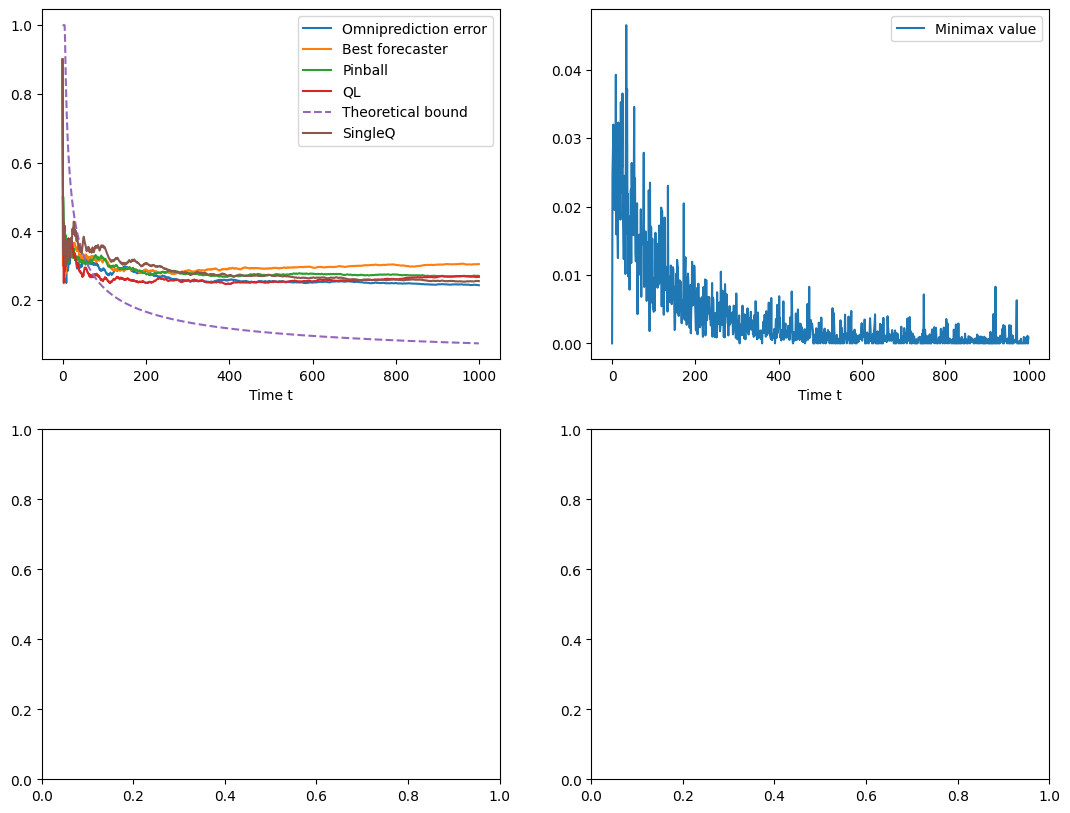

In [189]:
def simple_plot(results: dict):
    """Plot omniprediction experiment results."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    ax = axes[0,0]
    ax.plot(np.arange(results['T']), results['omni_score_trace'], label='Omniprediction error')
    ax.plot(np.arange(results['T']), results['best_forecaster_score_trace'], label='Best forecaster')
    ax.plot(np.arange(results['T']), pinball_omni_score_trace, label='Pinball')
    ax.plot(np.arange(results['T']), ql_omni_score_trace, label='QL')
    ax.plot(np.arange(results['T']), [np.minimum(np.sqrt(np.log(results['m'] * results['F']) / t), 1.0) for t in np.arange(results['T'])], '--', label='Theoretical bound')
    ax.set_xlabel('Time t')
    ax.legend()

    ax = axes[0,1]
    ax.plot(np.arange(results['T']), results['minimax_value_history'], label='Minimax value')
    ax.set_xlabel('Time t')
    ax.legend()

    return fig, axes

fig, axes = simple_plot(results)

# single_q version
singleq_omni_score_trace_list = []
for alpha in alpha_list:
    singleq_omni_score_trace_list.append(results_dict[alpha]['omni_score_trace'])
singleq_df = np.stack(singleq_omni_score_trace_list, axis=1)    # (T, F)
singleq_omni_trace = singleq_df.max(axis=1)
axes[0,0].plot(np.arange(T), singleq_omni_trace, label='SingleQ')
axes[0,0].legend()


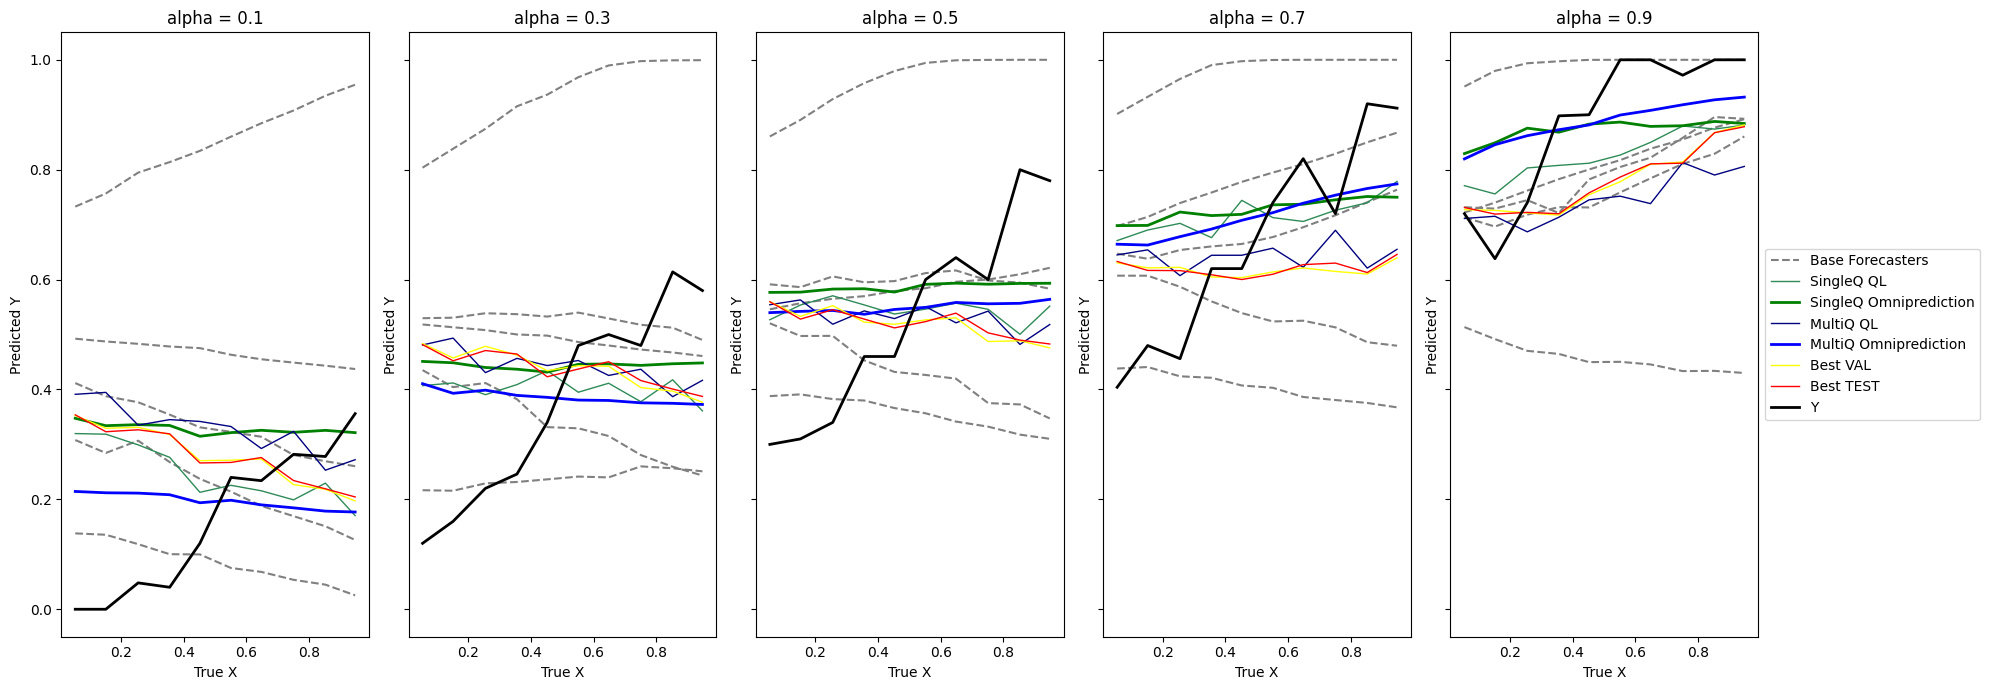

In [ ]:
import pandas as pd
import scipy.stats as stats

X = results['X']    # (T, )
Y = results['Y']    # (T, )
phat_history = results['phat_history']    # (T, N)
forecasters_preds_history = results['forecasters_preds_history']    # (T, N, F)
pinball_preds_history = results['pinball_preds_history']
ql_preds_history = results['ql_preds_history']

# Best Value
forecasters_score_trace = results['forecasters_score_trace']   # (T, F)
best_val_forecaster = np.concatenate([[0], np.argmin(forecasters_score_trace, axis=1)[:-1]])   # [0] as padding to look one step before
best_val_forecaster_error = forecasters_score_trace[np.arange(T), best_val_forecaster]
best_val_forecaster_preds = forecasters_preds_history[np.arange(T), :, best_val_forecaster]

best_test_forecaster = np.argmin(forecasters_score_trace, axis=1)
best_test_forecaster_error = forecasters_score_trace[np.arange(T), best_test_forecaster]     # (T, )
best_test_forecaster_preds = forecasters_preds_history[np.arange(T), :, best_test_forecaster]   # (T, N)

fig, ax = plt.subplots(1, len(alpha_list), figsize=(20, 7), sharey=True)

for ia, alpha in enumerate(alpha_list):
    singleq_omni_history = results_dict[alpha]['phat_history']
    df = pd.DataFrame(np.concatenate([X[:, None],
                                    phat_history[:, ia][:, None], 
                                    singleq_omni_history, 
                                    forecasters_preds_history[:, ia, :], 
                                    best_val_forecaster_preds[:, ia][:, None], 
                                    best_test_forecaster_preds[:, ia][:, None],
                                    pinball_preds_history[:, ia][:, None], 
                                    ql_preds_history[:, ia][:, None], 
                                    Y[:, None]
                                    ], 
                                    axis=1
                                    ),
                                    columns=['X', 'phat', 'singleq_phat', 'pred_1', 'pred_2', 'pred_3', 'pred_4', 'pred_5', 'best_val_pred', 'best_test_pred', 'pinball_pred', 'ql_pred', 'Y']
                                    )

    df['X_bin'] = pd.cut(df.iloc[:, 0], bins=10)
    binned_df = df.groupby('X_bin').mean(numeric_only=True)

    for j in range(F):
        line, = ax[ia].plot(binned_df.iloc[:, 0], binned_df[f'pred_{j+1}'], linestyle='--', color='gray')  # no label first
        if j == 0:
            line.set_label('Base Forecasters')
    # ax[ia].plot(binned_df.iloc[:, 0], binned_df.iloc[:, 0] * 0.2 + 0.5 + 0.3*stats.norm.ppf(alpha), color='black', linewidth=2, label='True')
    
    ax[ia].plot(binned_df.iloc[:, 0], binned_df[f'pinball_pred'], color='seagreen', linewidth=1, label='SingleQ QL')
    ax[ia].plot(binned_df.iloc[:, 0], binned_df[f'singleq_phat'], color='green',linewidth=2, label='SingleQ Omniprediction')
    ax[ia].plot(binned_df.iloc[:, 0], binned_df[f'ql_pred'], color='navy', linewidth=1, label='MultiQ QL')
    ax[ia].plot(binned_df.iloc[:, 0], binned_df['phat'], color='blue', linewidth=2, label='MultiQ Omniprediction')
    ax[ia].plot(binned_df.iloc[:, 0], binned_df[f'best_val_pred'], color='yellow', linewidth=1, label='Best VAL')
    ax[ia].plot(binned_df.iloc[:, 0], binned_df[f'best_test_pred'], color='red', linewidth=1, label='Best TEST')
    ax[ia].plot(binned_df.iloc[:, 0], df.groupby('X_bin')['Y'].quantile(alpha), color='black', linewidth=2, label='Y')
    
    #ax[ia].fill_between(binned_df.iloc[:, 0], df.groupby('X_bin')['Y'].quantile(alpha), color='green', linewidth=2, label='Y')
    ax[ia].set_xlabel('True X')
    ax[ia].set_ylabel('Predicted Y')
    ax[ia].set_title(f'alpha = {alpha}')
    if ia == len(alpha_list) - 1:
        ax[ia].legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()
plt.show()
    

# QL seems more conservative and towards the center 0.5 AND have smaller omniprediction error CHECK
# Pinball loss does follow omniprediction pretty closely. CHECK why




# Omniprediction error calculation check for QL and Pinball, try Pinball with post-sort, and see pinball chooses different model for each quantile level CHECK
# What's happening for alpha=0.1? why is all the models predicting downward trend oppopsed to Y's upward trend?
# Index check

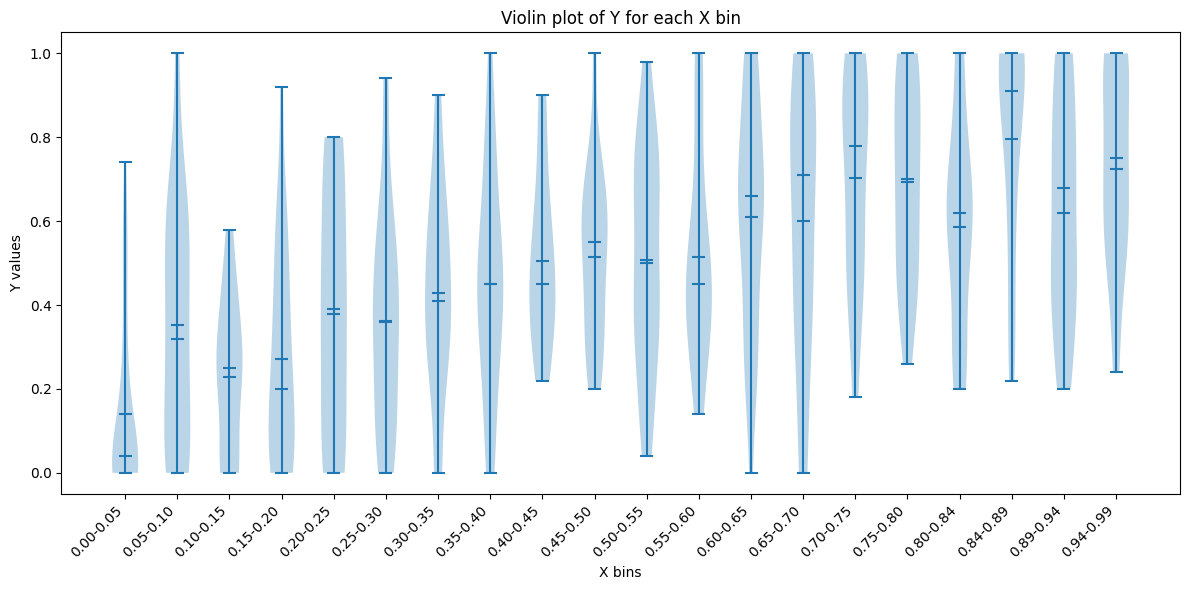

In [170]:
dfdf = pd.DataFrame({'X': results['X'], 'Y': results['Y']}).sort_values(by='X')

# bin dfdf using X, then draw violin plot of Y for each bin
dfdf['X_bin'] = pd.cut(dfdf['X'], bins=20)

# Get the ordered unique bins
bins = dfdf['X_bin'].cat.categories
# For each bin, get the Y values corresponding to that bin
data_per_bin = [dfdf[dfdf['X_bin'] == b]['Y'].values for b in bins]

fig, ax = plt.subplots(figsize=(12,6))
parts = ax.violinplot(data_per_bin, positions=np.arange(1, len(bins)+1), showmeans=True, showmedians=True)

# Set x-ticks to bin centers or labels
bin_labels = [f"{b.left:.2f}-{b.right:.2f}" for b in bins]
ax.set_xticks(np.arange(1, len(bins)+1))
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
ax.set_xlabel("X bins")
ax.set_ylabel("Y values")
ax.set_title("Violin plot of Y for each X bin")
plt.tight_layout()
plt.show()
